# Exploratory Data Analysis: Edmonton Restaurants

## Introduction

The restaurant industry in Edmonton is highly competitive, with a wide variety of cuisines, price levels, and dining formats available to consumers. Online platforms such as Google Maps provide rich, user-generated data that can be used to understand customer behavior, restaurant performance, and market dynamics.

In this analysis, we explore a dataset of Edmonton restaurants to uncover patterns in **ratings**, **review volumes**, **restaurant types**, **operating hours**, **price levels**, and **neighborhood distribution**. The goal of this exploratory data analysis (EDA) is to identify factors that may influence restaurant popularity and customer satisfaction.

Specifically, this notebook aims to answer the following questions:
- How restaurant ratings are distributed across Edmonton?
- How user reviews are concentrated among restaurants?
- Whether restaurant type affects popularity and performance?
- Whether operating hours and weekend availability influence ratings?
- Whether neighborhood characteristics are associated with restaurant density and quality?
- Whether price level is related to restaurant ratings and engagement?

The insights from this analysis can be useful for **restaurant owners**, **investors**, and **urban planners**, as well as serve as a practical demonstration of data exploration and visualization techniques using real-world data.

## Data Overview
This dataset contains information on restaurants located in Edmonton, collected from Google Maps. Each row represents a unique restaurant, along with attributes describing its **location**, **category**, **customer engagement**, and **operational characteristics**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/cleaned_restaurants.csv')
df.head()

,id,name,fsa_code,area,main_type,cuisine_group,price_level,rating,user_rating_count,menu_for_children,good_for_children,good_for_groups,accepts_non_cash,has_free_parking,has_paid_parking,open_24hrs,weekday_open_days,weekend_open_days,total_hrs,avg_daily_hrs,avg_weekday_hrs,avg_weekend_hrs
0,ChIJQWNpDe0YoFMRto7xgtIAHEk,Ecity Flame (Best Offer on Website),T6E,SouthBonnie Doon / EastUniversity,fast or casual dining,breakfast restaurant,inexpensive,4.0,749.0,True,True,True,True,True,False,False,5,2,93.0,13.285714,13.2,13.50
1,ChIJt4Bu_ksZoFMRR0pb8OvRXoQ,JT's Bar & Grill,T6K,WestMill Woods,beverage and bar,bar,moderate,4.3,884.0,False,False,True,True,True,False,False,5,2,102.0,14.571429,14.4,15.00
2,ChIJ44uK6H8YoFMR7-As8n-sr98,The Soban sushi & asian taste,T6B,SECapilano / WestSoutheast Industrial / East...,asian cuisine,japanese restaurant,moderate,4.6,732.0,False,True,True,True,True,False,False,5,2,60.0,8.571429,7.9,10.25
3,ChIJMf4TBj4ZoFMRTrRLBranVmU,Panago Pizza,T6L,EastMill Woods,delivery or takeaway,meal delivery,moderate,4.0,95.0,False,False,False,True,True,False,False,5,2,93.0,13.285714,13.2,13.50
4,ChIJWzGu-MMeoFMRzyGYhWapt5w,Mikado Southside,T6N,South Industrial,asian cuisine,japanese restaurant,expensive,4.3,1568.0,False,True,True,True,True,False,False,5,2,70.0,10.000000,10.0,10.00


In [3]:
df.shape

(712, 22)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 712 non-null    object 
 1   name               712 non-null    object 
 2   fsa_code           712 non-null    object 
 3   area               712 non-null    object 
 4   main_type          712 non-null    object 
 5   cuisine_group      712 non-null    object 
 6   price_level        712 non-null    object 
 7   rating             712 non-null    float64
 8   user_rating_count  712 non-null    float64
 9   menu_for_children  712 non-null    bool   
 10  good_for_children  712 non-null    bool   
 11  good_for_groups    712 non-null    bool   
 12  accepts_non_cash   712 non-null    bool   
 13  has_free_parking   712 non-null    bool   
 14  has_paid_parking   712 non-null    bool   
 15  open_24hrs         712 non-null    bool   
 16  weekday_open_days  712 non

In [6]:
df.describe()

,rating,user_rating_count,weekday_open_days,weekend_open_days,total_hrs,avg_daily_hrs,avg_weekday_hrs,avg_weekend_hrs
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,4.022051,874.824438,4.905899,1.905899,86.676030,12.612028,12.706461,12.175152
std,0.475480,1104.347648,0.328435,0.361072,33.364905,4.558515,4.547809,5.047230
min,2.200000,5.000000,2.000000,0.000000,20.000000,3.428571,3.500000,0.000000
25%,3.800000,271.750000,5.000000,2.000000,66.500000,10.000000,10.000000,9.000000
50%,4.100000,548.000000,5.000000,2.000000,83.000000,11.910714,12.000000,11.625000
75%,4.400000,1066.500000,5.000000,2.000000,99.000000,14.142857,14.200000,14.000000
max,5.000000,13009.000000,5.000000,2.000000,168.000000,24.000000,24.000000,24.000000


### Dataset Structure
- **Number of observations:** Each row corresponds to one restaurant
- **Geographic scope:** Edmonton, Canada
- **Data source:** Places API

### Key Variables
- **main_type**: Categorized type of restaurant (e.g. fast or casual dining, western cuisine, asian cuisine, beverage and bar, etc.).
- **rating**: Average user rating of the restaurant (typically on a 1–5 scale).
- **user_rating_count**: Number of user reviews submitted for the restaurant. Used as a proxy for restaurant popularity and customer engagement.
- **price_level**: Relative price category of the restaurant (e.g. inexpensive, moderate, expensive, very expensive).
- **avg_daily_hrs**: Average number of hours the restaurant operates per open day.
- **weekend_open_days**: Indicator of whether the restaurant is open on weekends.
- **area**: Edmonton neighborhood where the restaurant is located.

## Data Cleaning
Data cleaning and feature engineering were performed in a separate notebook to maintain modularity and clarity in the analysis workflow.

Key preprocessing steps included:
- Convert data types
- Extracting and standardizing nested attributes
- Engineering features related to weekday and weekend operations
- Handling missing values in critical fields

The cleaned dataset ([cleaned_restaurants.csv](data/cleaned_restaurants.csv)) is used throughout this notebook.  
The full data cleaning process can be found in the accompanying notebook: [03_data_cleaning.ipynb](03_data_cleaning.ipynb)

## How are restaurant ratings distributed across Edmonton?

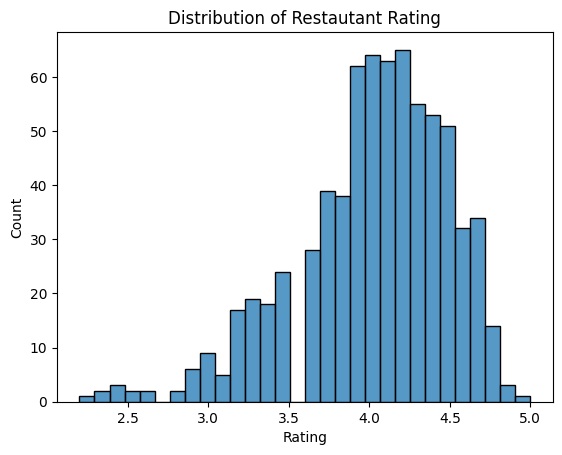

In [7]:
sns.histplot(df['rating'], bins=30)
plt.title('Distribution of Restautant Rating')
plt.xlabel('Rating')
plt.show()

### Insight
A histogram of restaurant ratings shows a clear peak around **3.8–4.2**. This indicates a strong positive bias in ratings, suggesting that most restaurants in Edmonton tend to receive relatively high scores, while very low ratings are uncommon.

### Implication
However, ratings alone may not sufficiently differentiate restaurant performance and should be interpreted alongside additional metrics such as review volume or operational charateristics.

## How concentrated are user reviews across restaurants?
The raw distribution of user rating counts is highly right-skewed, making it difficult to observe meaningful patterns.
Therefore, a log transformation was applied to improve interpretability.

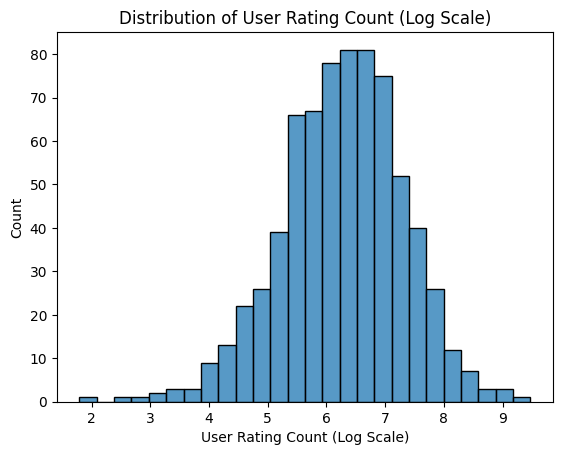

In [8]:
sns.histplot(np.log1p(df['user_rating_count']))
plt.title('Distribution of User Rating Count (Log Scale)')
plt.xlabel('User Rating Count (Log Scale)')
plt.show()

### Insight
After applying a log transformation, the distribution peaks between 6 and 7, corresponding to approximately 400–1,100 user reviews. This suggests that the majority of restaurants have moderate visibility on Google Maps, whereas only a small subset achieves very high customer engagement.

### Implication
Ratings based on a small number of reviews may be less reliable, suggesting that review volume should be considered when comparing restaurant ratings.

## Do restaurant types differ in both popularity and performance?

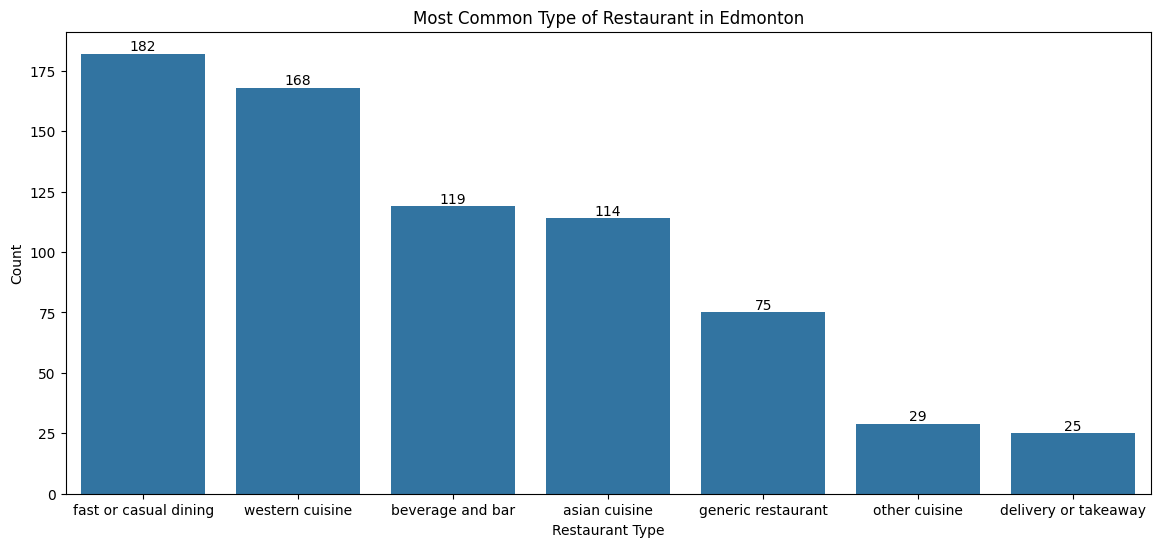

In [9]:
plt.figure(figsize=(14,6))
ax = sns.barplot(df['main_type'].value_counts())
ax.bar_label(ax.containers[0])
plt.title('Most Common Type of Restaurant in Edmonton')
plt.xlabel('Restaurant Type')
plt.ylabel('Count')
plt.show()

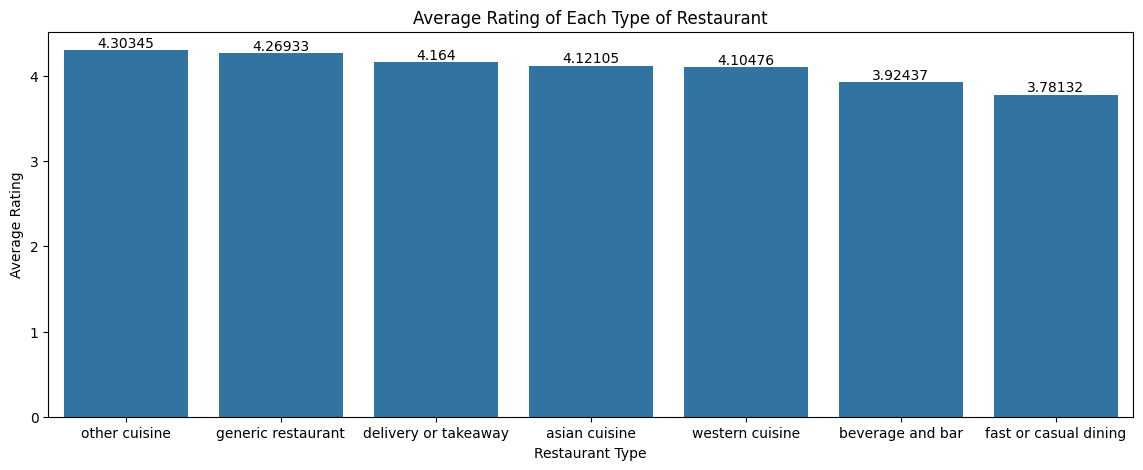

In [10]:
rating_per_type = df.groupby('main_type')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,5))
ax = sns.barplot(rating_per_type)
ax.bar_label(ax.containers[0])
plt.title('Average Rating of Each Type of Restaurant')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.show()

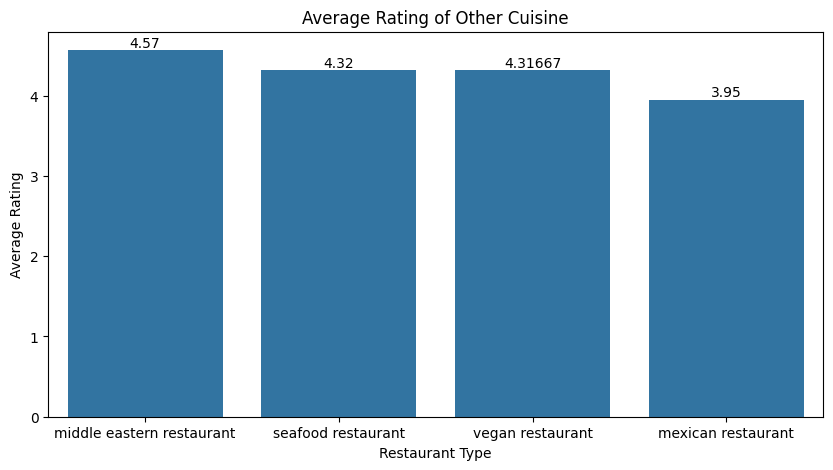

In [11]:
other_avg_rating = df[df['main_type']=='other cuisine'].groupby('cuisine_group')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(other_avg_rating)
ax.bar_label(ax.containers[0])
plt.title('Average Rating of Other Cuisine')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.show()

### Insight
Fast or casual dining and Western cuisine dominate the Edmonton restaurant landscape in terms of volume, yet they exhibit relatively lower average ratings. In contrast, smaller categories such as other cuisine and generic restaurants achieve higher average ratings despite fewer establishments.

### Implication
This pattern suggests a potential trade-off between scale and quality consistency. High-volume categories may face greater operational challenges, leading to more variability in customer experiences, while niche or less saturated categories may benefit from more focused offerings and clearer customer expectations.

## Do longer operating hours lead to higher ratings?

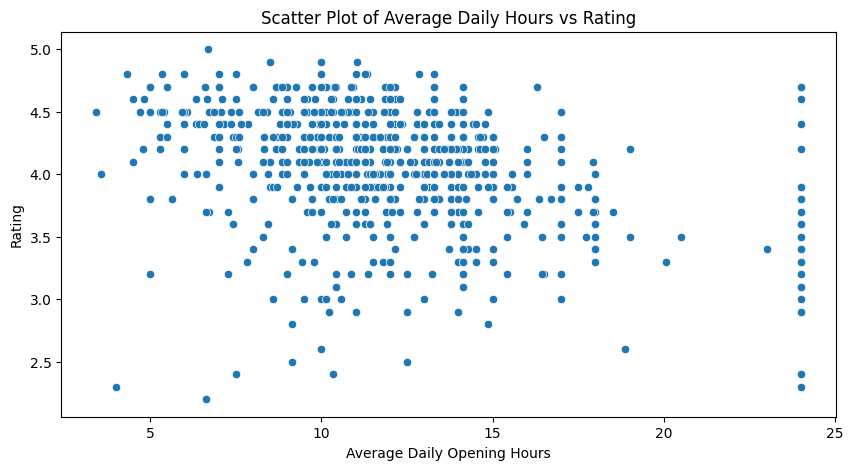

In [12]:
plt.figure(figsize=(10,5))
sns.scatterplot(df,x='avg_daily_hrs', y='rating')
plt.title('Scatter Plot of Average Daily Hours vs Rating')
plt.xlabel('Average Daily Opening Hours')
plt.ylabel('Rating')
plt.show()

### Insight
There is no clear linear relationship between average daily opening hours and restaurant ratings. Restaurants with longer hours do not consisitently receive higher ratings, suggesting diminishing returns beyond a certain operating threshold.

### Implication
Simply extending operating hours may not improve customer satisfaction. Restaurants may benefit more from optimizing service quality rather than increasing availability.

## Does weekend availability influence restaurant ratings?

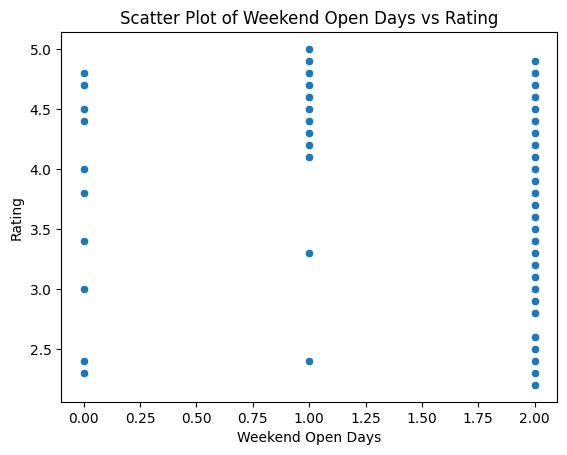

In [13]:
sns.scatterplot(df,x='weekend_open_days', y='rating')
plt.title('Scatter Plot of Weekend Open Days vs Rating')
plt.xlabel('Weekend Open Days')
plt.ylabel('Rating')
plt.show()

### Insight
Restaurants open on weekends do not show a strong rating advantage compared to those with limited weekend availability.

### Implication
Weekend availability alone may not be a key driver of customer satisfaction without complementary factors such as service quality or cuisine type.

## Are there neighborhood-level differences in restaurant density and ratings?

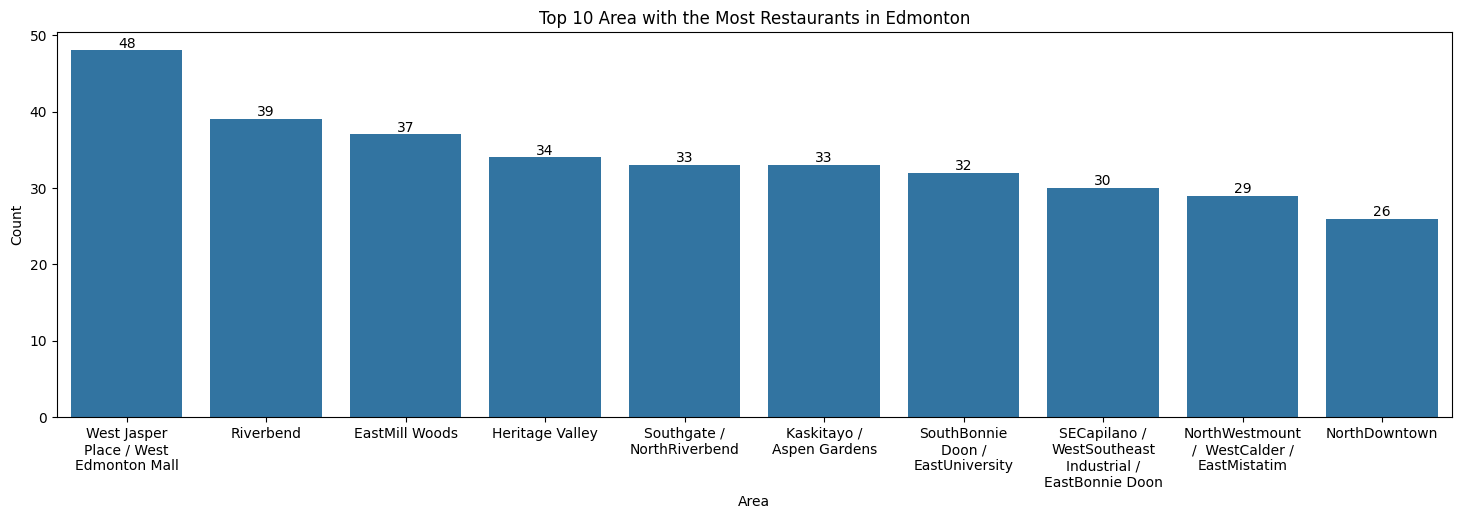

In [14]:
plt.figure(figsize=(18,5))
ax=sns.barplot(df['area'].value_counts().head(10))
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.bar_label(ax.containers[0])
plt.title('Top 10 Area with the Most Restaurants in Edmonton')
plt.xlabel('Area')
plt.ylabel('Count')
plt.show()

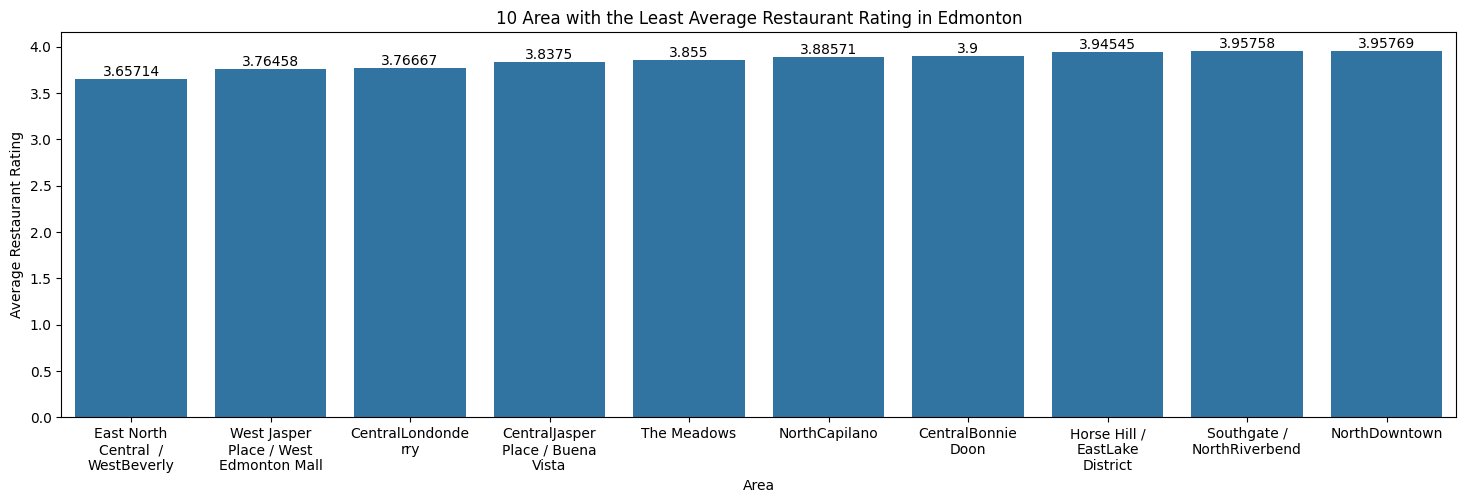

In [15]:
least5_rating_area = df.groupby('area')['rating'].mean().sort_values().head(10)

plt.figure(figsize=(18,5))
ax = sns.barplot(least5_rating_area)
labels = [textwrap.fill(label.get_text(), 15) for label in ax.get_xticklabels()]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.bar_label(ax.containers[0])
plt.title('10 Area with the Least Average Restaurant Rating in Edmonton')
plt.xlabel('Area')
plt.ylabel('Average Restaurant Rating')
plt.show()

### Insight
West Jasper Place / West Edmonton Mall, Southgate / NorthRiverbend, NorthDowntown contains one the highest concentration of restaurants in the dataset but also exhibit one of the lower average ratings, suggesting a more competitive and saturated dining environment.

### Implication
High restaurant density may intensify competition, making it more difficult for individual restaurants to maintain consistently high ratings in saturated areas.

## Is there a relationship between price level and ratings?

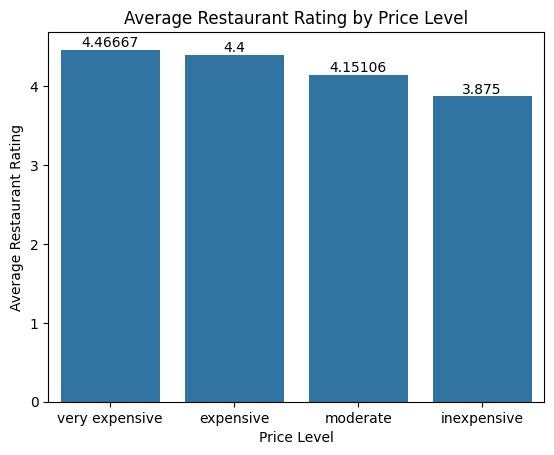

In [16]:
price_level_rating = df.groupby('price_level')['rating'].mean().sort_values(ascending=False)

ax = sns.barplot(price_level_rating)
ax.bar_label(ax.containers[0])
plt.title('Average Restaurant Rating by Price Level')
plt.xlabel('Price Level')
plt.ylabel('Average Restaurant Rating')
plt.show()

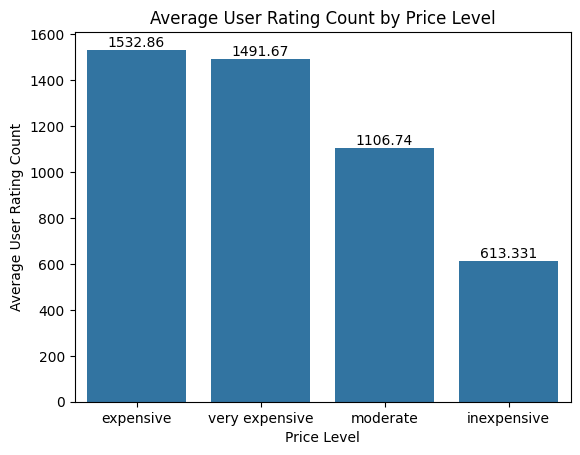

In [17]:
price_level_rating_count = df.groupby('price_level')['user_rating_count'].mean().sort_values(ascending=False)

ax = sns.barplot(price_level_rating_count)
ax.bar_label(ax.containers[0])
plt.title('Average User Rating Count by Price Level')
plt.xlabel('Price Level')
plt.ylabel('Average User Rating Count')
plt.show()

### Insight
Bar charts comparing price levels show that:
- More expensive restaurants generally receive higher average ratings.
- Higher-priced restaurants also tend to have more user reviews, indicating greater customer engagement.

### Implication
This relationship may partially reflect higher customer expectations and greater visibility rather than quality alone, suggesting that price level should be interpreted alongside review volume and category type.

## Final Summary
Overall, the Edmonton restaurant landscape is characterized by high average ratings, strong review engagement, and clear differences across restaurant types, price levels, and neighborhoods.  
While operating hours and weekend availability do not appear to influence ratings, factors such as restaurant type, price level, and location play a more meaningful role in customer perception and engagement.

## Limitations
- Ratings may suffer from positive bias, as dissatisfied customers are less likely to leave reviews.
- User rating count reflects engagement rather than true customer volume.
- Operating hours are averaged and may not capture peak-time availability.
- This analysis is observational and does not imply causal relationships.

## Recommendations
- **Restaurant owners** should focus more on food quality, service, and differentiation rather than extending operating hours.
- **New or niche cuisines** may have an advantage in achieving higher customer satisfaction despite lower market share.
- **Higher pricing strategies**, when supported by quality, may positively influence both ratings and review volume.
- **Urban planners or investors** should note that high restaurant density does not guarantee higher customer satisfaction, especially in areas like West Jasper Place / West Edmonton Mall.
- **Future analysis** could explore review sentiment, price-to-value perception, and temporal trends to gain deeper insights into customer behavior.

### Future Work
- Incorporate time-based data to study rating trends over time
- Control for review count when comparing ratings across categories
- Include customer sentiment from review text for deeper insights